#  ANALISIS CUSTOMER CHURN - TELCO CUSTOMER DATASET

## Import Library and Download Dataset

### Import Library

In [1]:
#Import Library
import kagglehub
import os
import warnings

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu, spearmanr

warnings.filterwarnings("ignore")


### Download & Load Dataset

In [2]:
# Download Dataset From Kagglehub
path = kagglehub.dataset_download("hassanelfattmi/why-do-customers-leave-can-you-spot-the-churners")

print("Path to dataset files:", path)
print("Files:")
print(os.listdir(path))

100%|██████████| 3.31M/3.31M [00:00<00:00, 132MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/hassanelfattmi/why-do-customers-leave-can-you-spot-the-churners/versions/5
Files:
['TELCO ER Diagram.png', 'Customer_Info.csv', 'Online_Services.csv', 'Status_Analysis.csv', 'Location_Data.csv', 'a_IBM Telco Customers Churn Datasets.xlsx', 'Payment_Info.csv', 'Service_Options.csv']


In [3]:
# Load Dataset
path = kagglehub.dataset_download(
    "hassanelfattmi/why-do-customers-leave-can-you-spot-the-churners"
)

print("Path to dataset files:", path)
print("Files:")
print(os.listdir(path))

DATA_DIR = path

files = {
    "status": "Status_Analysis.csv",
    "customer": "Customer_Info.csv",
    "payment": "Payment_Info.csv",
    "service": "Service_Options.csv",
    "online": "Online_Services.csv",
    "location": "Location_Data.csv",
}


def load_csv(file_name):
    """The only I/O helper kept from the original code."""
    file_path = os.path.join(DATA_DIR, file_name)
    if os.path.exists(file_path):
        print(f"Loaded: {file_name}")
        return pd.read_csv(file_path)
    print(f"File not found: {file_name}")
    return None


status = load_csv(files["status"])
customer = load_csv(files["customer"])
payment = load_csv(files["payment"])
service = load_csv(files["service"])
online = load_csv(files["online"])
location = load_csv(files["location"])

dataframes = {
    "status": status,
    "customer": customer,
    "payment": payment,
    "service": service,
    "online": online,
    "location": location,
}

for name, df_temp in dataframes.items():
    if df_temp is not None:
        print(f"\n{name.upper()} columns:")
        print(df_temp.columns.tolist())

for name, df_temp in dataframes.items():
    if df_temp is not None:
        print(f"{name}: {df_temp.shape}")

status.head()

Using Colab cache for faster access to the 'why-do-customers-leave-can-you-spot-the-churners' dataset.
Path to dataset files: /kaggle/input/why-do-customers-leave-can-you-spot-the-churners
Files:
['Status_Analysis.csv', 'Online_Services.csv', 'a_IBM Telco Customers Churn Datasets.xlsx', 'Customer_Info.csv', 'TELCO ER Diagram.png', 'Service_Options.csv', 'Location_Data.csv', 'Payment_Info.csv']
Loaded: Status_Analysis.csv
Loaded: Customer_Info.csv
Loaded: Payment_Info.csv
Loaded: Service_Options.csv
Loaded: Online_Services.csv
Loaded: Location_Data.csv

STATUS columns:
['customer_id', 'satisfaction_score', 'cltv', 'customer_status', 'churn_score', 'churn_label', 'churn_value', 'churn_category', 'churn_reason']

CUSTOMER columns:
['customer_id', 'gender', 'age', 'under_30', 'senior_citizen', 'partner', 'dependents', 'number_of_dependents', 'married']

PAYMENT columns:
['customer_id', 'contract', 'paperless_billing', 'payment_method', 'monthly_ charges', 'avg_monthly_long_distance_charges

,customer_id,satisfaction_score,cltv,customer_status,churn_score,churn_label,churn_value,churn_category,churn_reason
0,0002-ORFBO,3,2205,Stayed,65,No,0,Not Applicable,NaN
1,0003-MKNFE,5,5414,Stayed,66,No,0,Not Applicable,NaN
2,0004-TLHLJ,1,4479,Churned,71,Yes,1,Competitor,Competitor had better devices
3,0011-IGKFF,1,3714,Churned,91,Yes,1,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,1,3464,Churned,68,Yes,1,Dissatisfaction,Network reliability


All six source tables loaded successfully (status, customer, payment, service, online, location). They all share "customer_id" as the commonkey, so they can be merged into a single analysis table in the next step.
Check each table's row count above a table with a row count far off from the others is an early signal that a lot of missing values will show up after the merge.

### Merge Data

In [4]:
# Merge data
merged_df = None

for name, df in dataframes.items():
    if df is not None:
        if merged_df is None:
            merged_df = df
        else:
            merged_df = pd.merge(merged_df, df, on="customer_id", how="left")

print("Shape of the merged DataFrame:", merged_df.shape)
print("Head of the merged DataFrame:")
print(merged_df.head())

merged_df.info()

Shape of the merged DataFrame: (7043, 53)
Head of the merged DataFrame:
  customer_id  satisfaction_score  cltv customer_status  churn_score  \
0  0002-ORFBO                   3  2205          Stayed           65   
1  0003-MKNFE                   5  5414          Stayed           66   
2  0004-TLHLJ                   1  4479         Churned           71   
3  0011-IGKFF                   1  3714         Churned           91   
4  0013-EXCHZ                   1  3464         Churned           68   

  churn_label  churn_value   churn_category                   churn_reason  \
0          No            0   Not Applicable                            NaN   
1          No            0   Not Applicable                            NaN   
2         Yes            1       Competitor  Competitor had better devices   
3         Yes            1  Dissatisfaction        Product dissatisfaction   
4         Yes            1  Dissatisfaction            Network reliability   

   gender  ...  streaming_

 The merge uses a "left join" on customer_id, so the resulting row count should match the first table's (status) row count. If it's higher, that means some customer_id is duplicated in one of the other tables and needs to be checked.

In [5]:
# Check Duplicate Columns From The Merge

duplicate_check_cols = [
    ("internet_service_x", "internet_service_y"),
    ("phone_service_x", "phone_service_y"),
]

for col_x, col_y in duplicate_check_cols:
    if col_x in merged_df.columns and col_y in merged_df.columns:
        print(f"\nChecking {col_x} vs {col_y}")
        print(pd.crosstab(merged_df[col_x], merged_df[col_y]))


Checking internet_service_x vs internet_service_y
internet_service_y    No   Yes
internet_service_x            
No                  1526     0
Yes                    0  5517

Checking phone_service_x vs phone_service_y
phone_service_y   No   Yes
phone_service_x           
No               682     0
Yes                0  6361


Duplicate columns appeared after merging service-related tables, such as internet_service_x, internet_service_y, phone_service_x, and phone_service_y. After validation using cross-tabulation, both column pairs had identical values, so they were consolidated into single columns: internet_service and phone_service.

In [6]:
# Clean duplicate kolom
merged_df.drop(columns=["internet_service_y", "phone_service_y"], inplace=True)
merged_df.rename(columns={"internet_service_x": "internet_service", "phone_service_x": "phone_service"}, inplace=True)

In [7]:
merged_df.columns.tolist()

['customer_id',
 'satisfaction_score',
 'cltv',
 'customer_status',
 'churn_score',
 'churn_label',
 'churn_value',
 'churn_category',
 'churn_reason',
 'gender',
 'age',
 'under_30',
 'senior_citizen',
 'partner',
 'dependents',
 'number_of_dependents',
 'married',
 'contract',
 'paperless_billing',
 'payment_method',
 'monthly_ charges',
 'avg_monthly_long_distance_charges',
 'total_charges',
 'total_refunds',
 'total_extra_data_charges',
 'total_long_distance_charges',
 'total_revenue',
 'tenure',
 'internet_service',
 'phone_service',
 'multiple_lines',
 'avg_monthly_gb_download',
 'unlimited_data',
 'offer',
 'referred_a_friend',
 'number_of_referrals',
 'online_security',
 'online_backup',
 'device_protection',
 'premium_tech_support',
 'streaming_tv',
 'streaming_movies',
 'streaming_music',
 'internet_type',
 'country',
 'state',
 'city',
 'zip_code',
 'total_population',
 'latitude',
 'longitude']

## Data Preparation


### Data Cleaning

In [8]:
# Cek Missing Values
print("Missing values before handling:")
print(merged_df.isna().sum())

Missing values before handling:
customer_id                             0
satisfaction_score                      0
cltv                                    0
customer_status                         0
churn_score                             0
churn_label                             0
churn_value                             0
churn_category                          0
churn_reason                         5174
gender                                  0
age                                     0
under_30                                0
senior_citizen                          0
partner                                 0
dependents                              0
number_of_dependents                    0
married                                 0
contract                                0
paperless_billing                       0
payment_method                          0
monthly_ charges                        0
avg_monthly_long_distance_charges       0
total_charges                           0
to

Missing values in "offer", "churn_reason", and "internet_type" aren't randomly missing — they're a logical consequence: customers who never received a promo, never churned, or never subscribed to internet will naturally be blank on those columns. The right imputation is therefore an explicit label ("No Offer", "Not Churned", "No Internet Service"), not deletion or a mean fill.

In [9]:
# Handle Missing Values
merged_df["offer"].fillna("No Offer", inplace=True)
merged_df["churn_reason"].fillna("Not Churned", inplace=True)
merged_df['internet_type'].fillna('No Internet Service', inplace=True)

# Check
df_clean = merged_df
missing_after = df_clean.isna().sum().sort_values(ascending=False)
missing_after[missing_after > 0]

,0


No missing values remain in the key columns, and no fully duplicated rows were found. The dataset is clean and ready for column selection & feature engineering.

In [10]:
# Duplicate
df_clean.duplicated().sum()

np.int64(0)

In [11]:
df_clean.columns

Index(['customer_id', 'satisfaction_score', 'cltv', 'customer_status',
       'churn_score', 'churn_label', 'churn_value', 'churn_category',
       'churn_reason', 'gender', 'age', 'under_30', 'senior_citizen',
       'partner', 'dependents', 'number_of_dependents', 'married', 'contract',
       'paperless_billing', 'payment_method', 'monthly_ charges',
       'avg_monthly_long_distance_charges', 'total_charges', 'total_refunds',
       'total_extra_data_charges', 'total_long_distance_charges',
       'total_revenue', 'tenure', 'internet_service', 'phone_service',
       'multiple_lines', 'avg_monthly_gb_download', 'unlimited_data', 'offer',
       'referred_a_friend', 'number_of_referrals', 'online_security',
       'online_backup', 'device_protection', 'premium_tech_support',
       'streaming_tv', 'streaming_movies', 'streaming_music', 'internet_type',
       'country', 'state', 'city', 'zip_code', 'total_population', 'latitude',
       'longitude'],
      dtype='object')

In [12]:
# SELECT COLUMNS FOR ANALYSIS
selected_cols = [
    # ID & Target
    "customer_id", "customer_status", "churn_label", "churn_value",
    "churn_score", "satisfaction_score", "cltv", "churn_reason",
    # Customer Profile
    "gender", "age", "married", "dependents",
    # Contract & Payment
    "contract", "paperless_billing", "payment_method",
    "monthly_ charges", "total_charges", "total_revenue",
    # Tenure & Engagement
    "tenure", "offer", "referred_a_friend",
    # Services
    "internet_service", "internet_type", "phone_service", "multiple_lines",
    "online_security", "online_backup", "device_protection",
    "premium_tech_support", "streaming_tv", "streaming_movies",
    "streaming_music",
    # Location
    "country", "state", "city", "latitude", "longitude",
]

df_analysis = df_clean[selected_cols].copy()
print("df_analysis shape:", df_analysis.shape)
df_analysis.info()

df_analysis shape: (7043, 37)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 37 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           7043 non-null   object 
 1   customer_status       7043 non-null   object 
 2   churn_label           7043 non-null   object 
 3   churn_value           7043 non-null   int64  
 4   churn_score           7043 non-null   int64  
 5   satisfaction_score    7043 non-null   int64  
 6   cltv                  7043 non-null   int64  
 7   churn_reason          7043 non-null   object 
 8   gender                7043 non-null   object 
 9   age                   7043 non-null   int64  
 10  married               7043 non-null   object 
 11  dependents            7043 non-null   object 
 12  contract              7043 non-null   object 
 13  paperless_billing     7043 non-null   object 
 14  payment_method        7043 non-null   obje

### Feature Engineering

In [13]:
# Feature Engineering
# Age Group
df_analysis["age_group"] = pd.cut(
    df_analysis["age"], bins=[0, 25, 45, 65, 100],
    labels=["Young Adult", "Adult", "Mature", "Senior"],
)

# Tenure Group
df_analysis["tenure_group"] = pd.cut(
    df_analysis["tenure"], bins=[-1, 6, 12, 24, 48, 100],
    labels=["New Customer", "Short Tenure", "Medium Tenure",
            "Loyal Customer", "Long-Term Customer"],
)

# Monthly Charge Group
df_analysis["monthly_charge_group"] = pd.qcut(
    df_analysis["monthly_ charges"], q=3,
    labels=["Low Charge", "Medium Charge", "High Charge"],
    duplicates="drop",
)

# Satisfaction Group
df_analysis["satisfaction_group"] = pd.cut(
    df_analysis["satisfaction_score"], bins=[0, 2, 3, 5],
    labels=["Low Satisfaction", "Neutral Satisfaction", "High Satisfaction"],
)

# Service Count
service_cols = [
    "phone_service", "multiple_lines", "online_security", "online_backup",
    "device_protection", "premium_tech_support", "streaming_tv",
    "streaming_movies", "streaming_music",
]

df_analysis["total_services_used"] = df_analysis[service_cols].apply(
    lambda row: sum(row.astype(str).str.lower() == "yes"), axis=1
)

# Customer Value Segment based on CLTV
df_analysis["cltv_segment"] = pd.qcut(
    df_analysis["cltv"], q=3,
    labels=["Low Value", "Medium Value", "High Value"],
    duplicates="drop",
)

print(df_analysis[[
    "age", "age_group", "tenure", "tenure_group",
    "monthly_ charges", "monthly_charge_group",
    "satisfaction_score", "satisfaction_group",
    "cltv", "cltv_segment", "total_services_used",
]].head())

   age age_group  tenure   tenure_group  monthly_ charges  \
0   37     Adult       9   Short Tenure              65.6   
1   46    Mature       9   Short Tenure              59.9   
2   50    Mature       4   New Customer              73.9   
3   78    Senior      13  Medium Tenure              98.0   
4   75    Senior       3   New Customer              83.9   

  monthly_charge_group  satisfaction_score    satisfaction_group  cltv  \
0        Medium Charge                   3  Neutral Satisfaction  2205   
1        Medium Charge                   5     High Satisfaction  5414   
2        Medium Charge                   1      Low Satisfaction  4479   
3          High Charge                   1      Low Satisfaction  3714   
4        Medium Charge                   1      Low Satisfaction  3464   

   cltv_segment  total_services_used  
0     Low Value                    4  
1    High Value                    4  
2  Medium Value                    2  
3     Low Value                 

Six derived features were created so numerical variables can be analyzed categorically (needed for the Chi-Square test later) and so they're easier to read for a non-technical audience.

## Exploratory Data Analysis

Total Customers: 7043
Total Churned: 1869
Total Not Churned: 5174
Overall Churn Rate: 26.54%


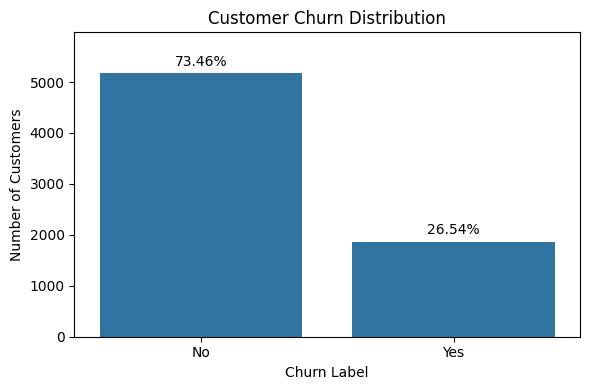

In [14]:
# OVERALL CHURN RATE

total_customers = df_analysis["customer_id"].nunique()
total_churned = df_analysis[df_analysis["churn_value"] == 1]["customer_id"].nunique()
total_not_churned = df_analysis[df_analysis["churn_value"] == 0]["customer_id"].nunique()
churn_rate = total_churned / total_customers * 100

print("Total Customers:", total_customers)
print("Total Churned:", total_churned)
print("Total Not Churned:", total_not_churned)
print(f"Overall Churn Rate: {churn_rate:.2f}%")

plt.figure(figsize=(6, 4))

ax = sns.countplot(data=df_analysis,
    x="churn_label")

for container in ax.containers:
    labels = [
        f"{value / total_customers * 100:.2f}%"
        for value in container.datavalues
    ]
    ax.bar_label(container, labels=labels, padding=3)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Label")
plt.ylabel("Number of Customers")
plt.ylim(0, ax.get_ylim()[1] * 1.1)
plt.tight_layout()
plt.show()

 **Overall churn rate is 26.54%,** roughly **1 in 4 customers has churned**. This number becomes the baseline for comparison: any category with a churn rate above 26.54% in the following analyses is riskier than average, and vice versa.

In [15]:
# Churn Rate by Category
def churn_summary_by_category(data, category_col):
    summary = data.groupby(category_col).agg(
        total_customers=("customer_id", "nunique"),
        churned_customers=("churn_value", "sum"),
        churn_rate=("churn_value", "mean")
    ).reset_index()

    summary["churn_rate"] = summary["churn_rate"] * 100
    summary = summary.sort_values("churn_rate", ascending=False)

    return summary


def plot_churn_rate(data, category_col, title):
    summary = churn_summary_by_category(data, category_col)

    plt.figure(figsize=(9,5))
    sns.barplot(
        data=summary,
        x=category_col,
        y="churn_rate"
    )
    plt.title(title)
    plt.xlabel(category_col)
    plt.ylabel("Churn Rate (%)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    display(summary)

    return summary

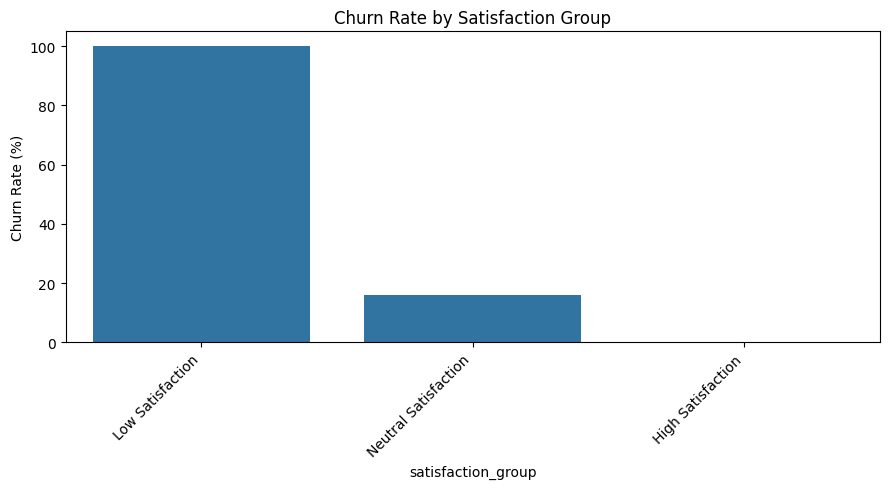

,satisfaction_group,total_customers,churned_customers,churn_rate
0,Low Satisfaction,1440,1440,100.000000
1,Neutral Satisfaction,2665,429,16.097561
2,High Satisfaction,2938,0,0.000000


In [16]:
churn_satisfaction = plot_churn_rate(
    df_analysis,
    "satisfaction_group",
    "Churn Rate by Satisfaction Group"
)

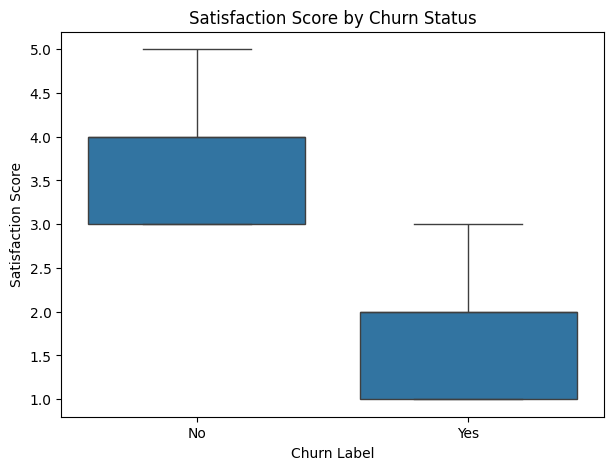

In [17]:
plt.figure(figsize=(7,5))
sns.boxplot(
    data=df_analysis,
    x="churn_label",
    y="satisfaction_score"
)
plt.title("Satisfaction Score by Churn Status")
plt.xlabel("Churn Label")
plt.ylabel("Satisfaction Score")
plt.show()

Customer satisfaction shows a clear relationship with churn. All 1,440 customers in the** Low Satisfaction (1-2)** group had churned, resulting in a churn rate of **100%**. In the **Neutral Satisfaction** group, 429 out of 2,665 customers had churned, with a churn rate of **16.10%**. Meanwhile, the **High Satisfaction** group recorded no churn among 2,938 customers.

This pattern indicates that customers with lower satisfaction are considerably more likely to leave, while highly satisfied customers tend to remain with the company. Therefore, satisfaction surveys can be used as an  monitoring tool to identify signs of dissatisfaction early. Customers reporting low satisfaction should receive prompt complaint resolution, service evaluation, and proactive follow-up before their dissatisfaction leads to churn.

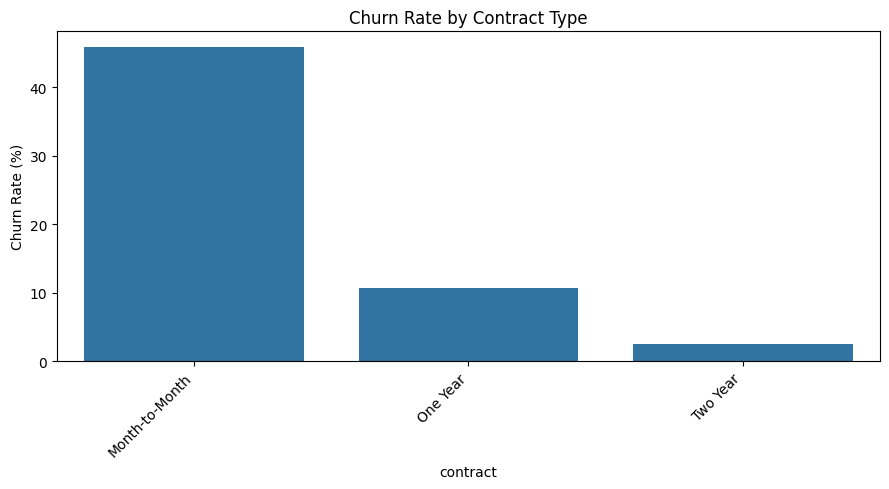

,contract,total_customers,churned_customers,churn_rate
0,Month-to-Month,3610,1655,45.844875
1,One Year,1550,166,10.709677
2,Two Year,1883,48,2.549124


In [18]:
# Churn by Contract Type
churn_contract = plot_churn_rate(
    df_analysis,
    "contract",
    "Churn Rate by Contract Type"
)

Contract type shows a clear relationship with customer churn. Customers with **Month-to-Month** contracts recorded the highest churn rate at **45.84%**, with 1,655 out of 3,610 customers leaving the service.

The churn rate decreased substantially among customers with longer contracts. Customers with a **One-Year** contract had a churn rate of **10.71%**, while customers with a **Two-Year** contract recorded the lowest churn rate at only ** 2.55%.**

This pattern indicates that customers with short-term contracts are more vulnerable to churn, while longer-term contracts are associated with stronger customer retention. Therefore, Month-to-Month customers should be monitored more closely and encouraged to move to longer-term contracts through loyalty benefits, discounted rates, or renewal incentives.

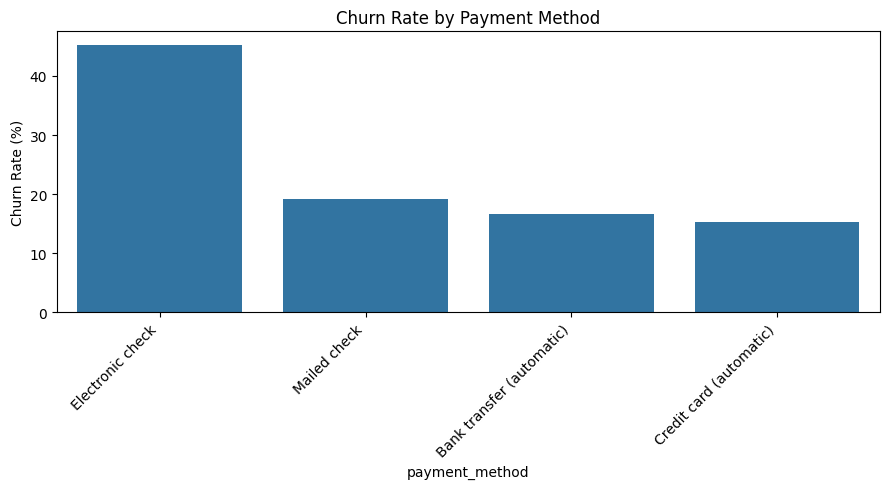

,payment_method,total_customers,churned_customers,churn_rate
2,Electronic check,2365,1071,45.285412
3,Mailed check,1612,308,19.106700
0,Bank transfer (automatic),1544,258,16.709845
1,Credit card (automatic),1522,232,15.243101


In [19]:
# Churn Rate by Payment Method
churn_payment = plot_churn_rate(
    df_analysis,
    "payment_method",
    "Churn Rate by Payment Method"
)

Customers using **Electronic Check** recorded the highest churn rate at **45.29%**, with 1,071 out of 2,365 customers leaving the service. This rate was substantially higher than the other payment methods.

Customers using Mailed Check had a churn rate of 19.11%, while customers using automatic payment methods showed lower churn rates. Bank Transfer (Automatic) recorded a churn rate of 16.71%, and Credit Card (Automatic) had the lowest churn rate at 15.24%.

This pattern indicates that customers using Electronic Check are more vulnerable to churn, while automatic payment methods are associated with better customer retention. Therefore, Electronic Check customers should be monitored more closely and encouraged to switch to automatic payment methods through easier enrollment, payment reminders, or small incentives.

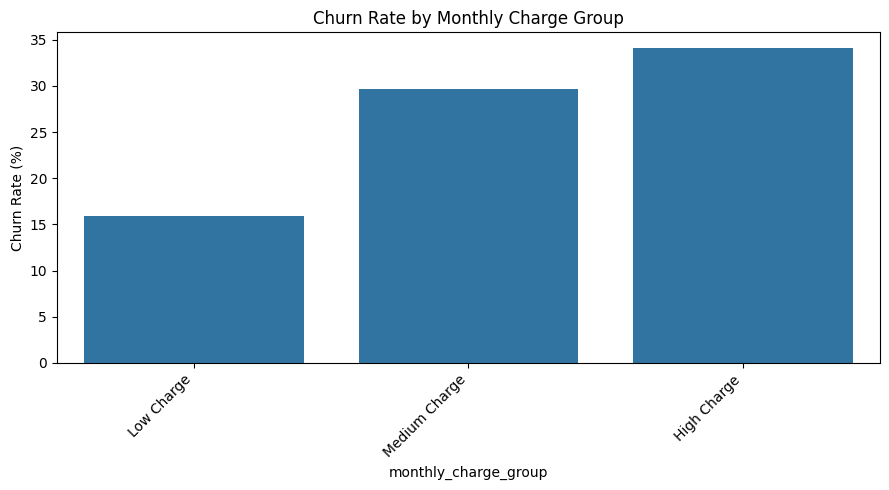

,monthly_charge_group,total_customers,churned_customers,churn_rate
2,High Charge,2347,800,34.086067
1,Medium Charge,2345,696,29.680171
0,Low Charge,2351,373,15.865589


In [20]:
# Churn Rate by Monthly Charge Group
churn_monthly_charge = plot_churn_rate(
    df_analysis,
    "monthly_charge_group",
    "Churn Rate by Monthly Charge Group"
)

Customers in the **High Charge** group recorded the highest churn rate at 3**4.09%**, with 800 out of 2,347 customers leaving the service. The **Medium Charge** group followed with a churn rate of 29.68%, while the Low Charge group had the lowest churn rate at 15.87%.

This pattern indicates that churn tends to increase as monthly charges become higher. Customers paying higher fees may have greater expectations regarding service quality, reliability, and customer support. When the perceived value does not match the amount paid, they may be more likely to switch providers.

Therefore, customers in the High Charge group should be monitored more closely through satisfaction surveys, service-quality reviews, and proactive follow-ups. The company should also evaluate whether its higher-priced packages provide sufficient value and benefits to justify their cost

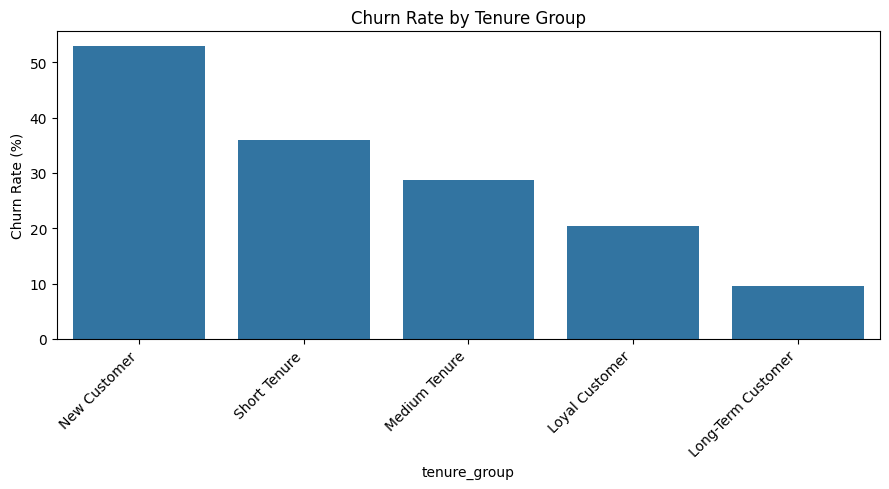

,tenure_group,total_customers,churned_customers,churn_rate
0,New Customer,1481,784,52.937205
1,Short Tenure,705,253,35.886525
2,Medium Tenure,1024,294,28.710938
3,Loyal Customer,1594,325,20.388959
4,Long-Term Customer,2239,213,9.513176


In [21]:
# Churn Rate by Tenure Group
churn_tenure = plot_churn_rate(
    df_analysis,
    "tenure_group",
    "Churn Rate by Tenure Group"
)

Customers in the **New Customer** group recorded the highest churn rate at 52.94%, with 784 out of 1,481 customers leaving the service. The churn rate then gradually decreased as customer tenure increased.

The **Short Tenure** group had a churn rate of 35.89%, followed by Medium Tenure at 28.71% and Loyal Customer at 20.39%. Meanwhile, Long-Term Customers recorded the lowest churn rate at only 9.51%.

This pattern indicates that customers are most vulnerable during the early stages of their relationship with the company. As customers remain longer, they are more likely to develop familiarity, trust, and loyalty toward the service.

Therefore, the company should strengthen the early customer experience through structured onboarding, service-quality checks, satisfaction surveys, and proactive follow-ups during the first few months. Early intervention can help identify dissatisfaction before it leads to churn.

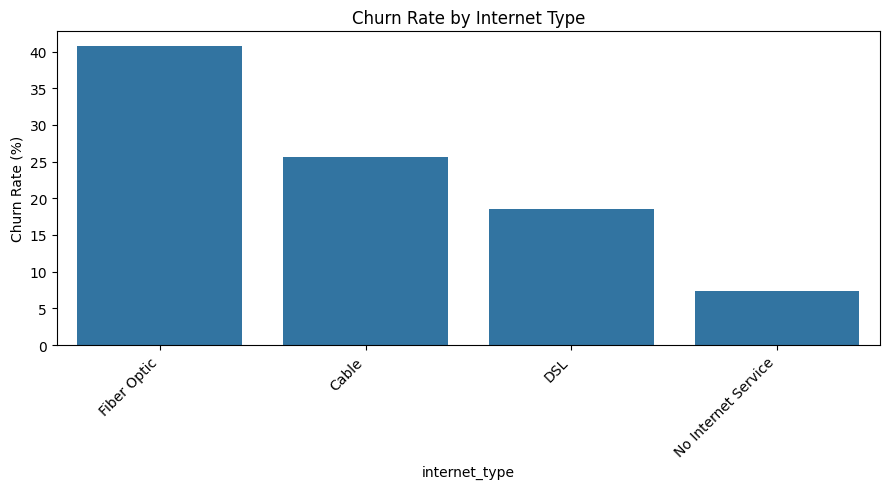

,internet_type,total_customers,churned_customers,churn_rate
2,Fiber Optic,3035,1236,40.724876
0,Cable,830,213,25.662651
1,DSL,1652,307,18.583535
3,No Internet Service,1526,113,7.404980


In [22]:
# Churn Rate by Internet Type
churn_internet_type = plot_churn_rate(
    df_analysis,
    "internet_type",
    "Churn Rate by Internet Type"
)

Customers using **Fiber Optic **recorded the highest churn rate at **40.72%**, with 1,236 out of 3,035 customers leaving the service. This was followed by Cable customers with a churn rate of 25.66% and DSL customers with 18.58%.

Meanwhile, customers with No Internet Service had the lowest churn rate at 7.40%. However, this does not necessarily mean that not using internet services improves retention, as these customers may have different service needs and lower overall service complexity.

The high churn rate among Fiber Optic customers indicates that this segment may experience a gap between service expectations and the value received. Since Fiber Optic is generally positioned as a higher-quality service, customers may have stronger expectations regarding connection stability, speed, pricing, and technical support.

Therefore, the company should review the Fiber Optic customer experience by monitoring network quality, service complaints, pricing, and satisfaction survey results. Proactive follow-ups should be prioritized for dissatisfied Fiber Optic customers to identify and resolve service issues before they decide to leave.

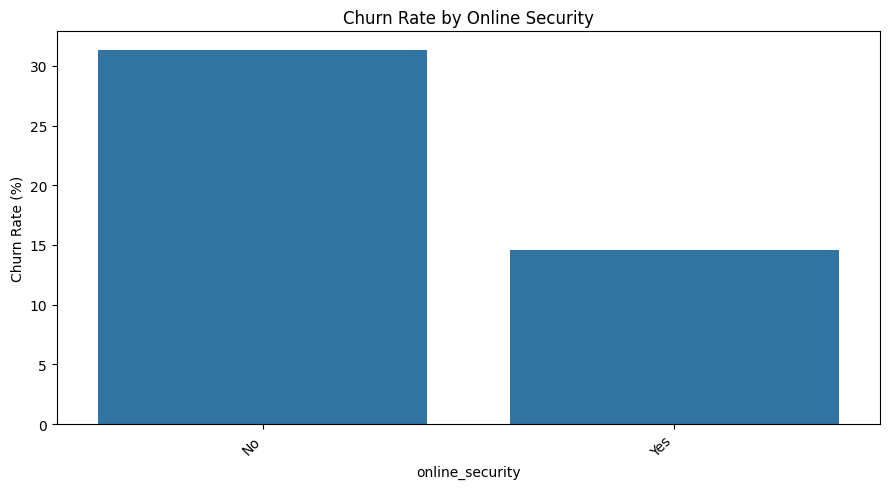

,online_security,total_customers,churned_customers,churn_rate
0,No,5024,1574,31.329618
1,Yes,2019,295,14.611194


In [23]:
churn_online_security = plot_churn_rate(
    df_analysis,
    "online_security",
    "Churn Rate by Online Security"
)

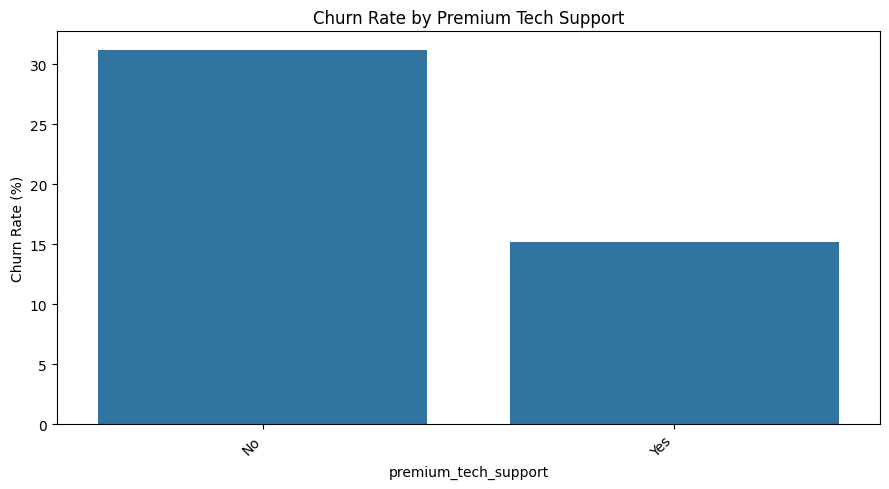

,premium_tech_support,total_customers,churned_customers,churn_rate
0,No,4999,1559,31.186237
1,Yes,2044,310,15.166341


In [24]:
# Churn Rate by Premium Tech Support
churn_tech_support = plot_churn_rate(
    df_analysis,
    "premium_tech_support",
    "Churn Rate by Premium Tech Support"
)

Customers **without Premium Tech Support** recorded a churn rate of ** 31.19%**, with 1,559 out of 4,999 customers leaving the service. In comparison, customers who used Premium Tech Support had a much lower churn rate of 15.17%.

This pattern indicates that customers with access to technical support tend to remain with the company longer. Reliable and responsive support may help customers resolve service issues before frustration develops into a decision to leave.

Therefore, the company should consider promoting Premium Tech Support to customers who frequently experience technical problems or show low satisfaction. Technical support quality should also be monitored through response time, issue-resolution rate, and post-service satisfaction surveys.

In [25]:
# Churn Reason Summary
churn_reason_summary = (
    df_analysis[df_analysis["churn_value"] == 1]
    .groupby("churn_reason")
    .agg(total_customers=("customer_id", "nunique"))
    .reset_index()
    .sort_values("total_customers", ascending=False)
)

churn_reason_summary["percentage"] = (
    churn_reason_summary["total_customers"]
    / churn_reason_summary["total_customers"].sum() * 100
)

churn_reason_summary.head(10)

,churn_reason,total_customers,percentage
2,Competitor had better devices,313,16.746923
3,Competitor made better offer,311,16.639914
1,Attitude of support person,220,11.771001
7,Don't know,130,6.955591
5,Competitor offered more data,117,6.260032
4,Competitor offered higher download speeds,100,5.350455
0,Attitude of service provider,94,5.029428
17,Price too high,78,4.173355
18,Product dissatisfaction,77,4.119850
14,Network reliability,72,3.852327


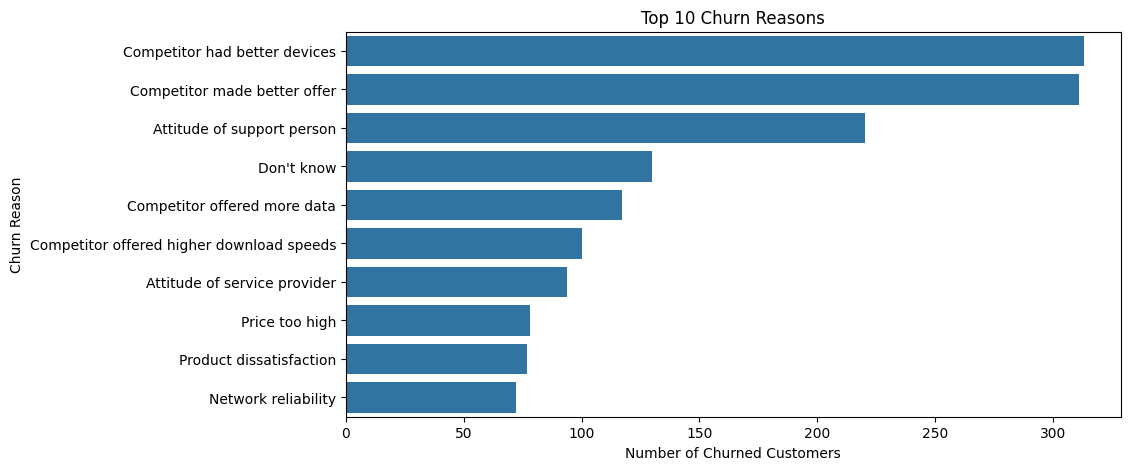

In [26]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=churn_reason_summary.head(10),
    x="total_customers",
    y="churn_reason"
)
plt.title("Top 10 Churn Reasons")
plt.xlabel("Number of Churned Customers")
plt.ylabel("Churn Reason")
plt.show()

The most frequently reported churn reasons were related to competitors. **Competitor Had Better Devices** was the leading reason, accounting for **16.75%** of churned customers, followed closely by **Competitor Made a Better Offer** at **16.64%**. Other competitor-related reasons included more attractive data packages and higher download speeds.

Customer service also contributed significantly to churn. **Attitude of Support Person** accounted for **11.77%**, while **Attitude of Service Provider** represented **5.03%**. This indicates that customers evaluate not only the product and price, but also the quality of their interactions with the company.

Additionally, **6.96%** of churned customers selected “Don’t Know,” suggesting that the company may not have captured their reasons clearly. Other concerns included high prices, product dissatisfaction, and network reliability.

Overall, churn is mainly driven by competitive offers and customer-service experience. The company should review its devices, pricing, data packages, and internet-speed value while improving support quality. Exit surveys should also be strengthened to capture more specific feedback from customers who leave.


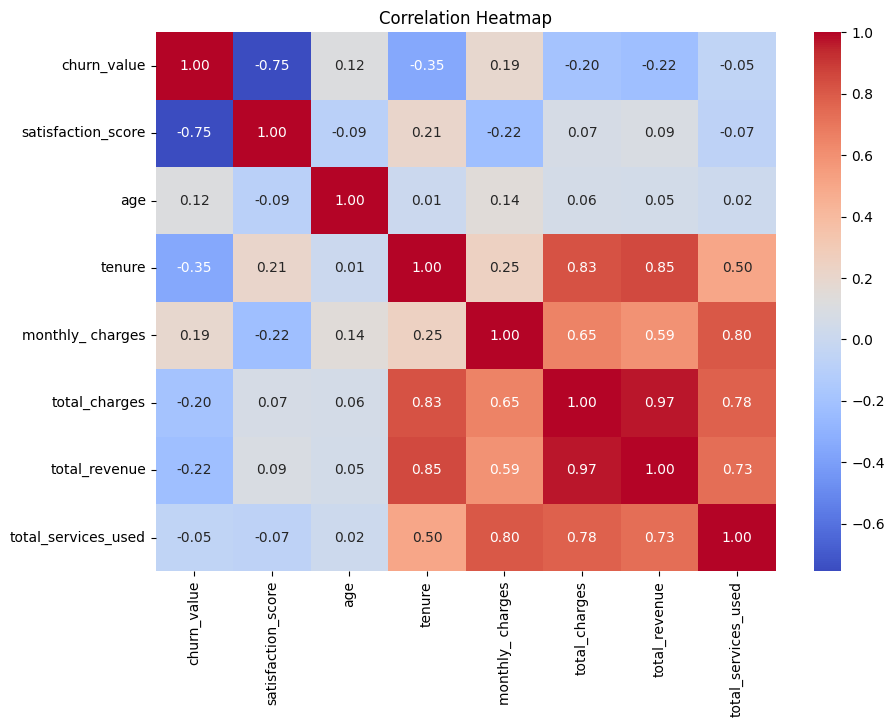

In [27]:
# Correlation Heatmap
corr_cols = [
    "churn_value",
    "satisfaction_score",
    "age",
    "tenure",
    "monthly_ charges",
    "total_charges",
    "total_revenue",
    "total_services_used"
]

corr_matrix = df_analysis[corr_cols].corr()

plt.figure(figsize=(10,7))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

The heatmap shows that satisfaction score has the strongest relationship with churn, with a correlation of -0.75. This strong negative relationship means that customers with higher satisfaction scores are much less likely to churn. Therefore, regular satisfaction surveys can be used as an important monitoring tool to identify dissatisfied customers and support early retention actions.

Customer tenure also has a negative correlation with churn at -0.35. This indicates that customers who have stayed longer tend to be less likely to leave, which supports the previous finding that new and short-tenure customers are more vulnerable to churn.

## Hypothesis Testing

In [28]:
# HYPOTHESIS TESTING SETUP

alpha = 0.05

print("Hypothesis for categorical variables:")
print("H0: There is no relationship between the categorical variable and churn.")
print("H1: There is a relationship between the categorical variable and churn.")

print("\nHypothesis for numerical variables:")
print("H0: There is no difference in the numerical variable between churned and not-churned customers.")
print("H1: There is a difference in the numerical variable between churned and not-churned customers.")

Hypothesis for categorical variables:
H0: There is no relationship between the categorical variable and churn.
H1: There is a relationship between the categorical variable and churn.

Hypothesis for numerical variables:
H0: There is no difference in the numerical variable between churned and not-churned customers.
H1: There is a difference in the numerical variable between churned and not-churned customers.


### Categorical Test

In [29]:
from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

# FUNCTION: CRAMER'S V

def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape

    return np.sqrt((chi2 / n) / min(k - 1, r - 1))


def interpret_cramers_v(v):
    if pd.isna(v):
        return "Not available"
    elif v < 0.10:
        return "Very Weak"
    elif v < 0.20:
        return "Weak"
    elif v < 0.40:
        return "Moderate"
    elif v < 0.60:
        return "Strong"
    else:
        return "Very Strong"

In [30]:
# CHI-SQUARE TEST

categorical_test_cols = [
    "gender",
    "married",
    "dependents",
    "contract",
    "paperless_billing",
    "payment_method",
    "offer",
    "referred_a_friend",
    "internet_service",
    "internet_type",
    "phone_service",
    "multiple_lines",
    "online_security",
    "online_backup",
    "device_protection",
    "premium_tech_support",
    "streaming_tv",
    "streaming_movies",
    "streaming_music",
    "age_group",
    "tenure_group",
    "monthly_charge_group",
    "satisfaction_group",
    "cltv_segment"
]

categorical_test_cols = [col for col in categorical_test_cols if col in df_analysis.columns]

chi_square_results = []

for col in categorical_test_cols:
    contingency_table = pd.crosstab(df_analysis[col], df_analysis["churn_value"])

    if contingency_table.shape[0] > 1 and contingency_table.shape[1] > 1:
        chi2, p_value, dof, expected = chi2_contingency(contingency_table)
        cramer_v = cramers_v(contingency_table)

        chi_square_results.append({
            "variable": col,
            "chi_square_statistic": chi2,
            "p_value": p_value,
            "cramers_v": cramer_v,
            "effect_size": interpret_cramers_v(cramer_v),
            "significant": "Yes" if p_value < alpha else "No",
            "conclusion": "Reject H0" if p_value < alpha else "Fail to Reject H0"
        })

chi_square_results_df = pd.DataFrame(chi_square_results)
chi_square_results_df = chi_square_results_df.sort_values(
    by=["significant", "cramers_v"],
    ascending=[False, False]
)

chi_square_results_df

,variable,chi_square_statistic,p_value,cramers_v,effect_size,significant,conclusion
22,satisfaction_group,5196.660636,0.000000e+00,0.858981,Very Strong,Yes,Reject H0
3,contract,1445.293243,0.000000e+00,0.453001,Strong,Yes,Reject H0
20,tenure_group,927.329275,1.995934e-199,0.362859,Moderate,Yes,Reject H0
9,internet_type,653.832054,2.150350e-141,0.304687,Moderate,Yes,Reject H0
5,payment_method,648.142327,3.682355e-140,0.303359,Moderate,Yes,Reject H0
6,offer,481.725489,7.020357e-102,0.261530,Moderate,Yes,Reject H0
2,dependents,433.734379,2.500972e-96,0.248161,Moderate,Yes,Reject H0
8,internet_service,364.519799,2.920300e-81,0.227500,Moderate,Yes,Reject H0
4,paperless_billing,258.277649,4.073355e-58,0.191498,Weak,Yes,Reject H0
21,monthly_charge_group,217.825941,5.008386e-48,0.175864,Weak,Yes,Reject H0


In [31]:
# TOP CATEGORICAL FACTORS

top_categorical_factors = chi_square_results_df[
    chi_square_results_df["significant"] == "Yes"
].sort_values("cramers_v", ascending=False)

top_categorical_factors.head(10)

,variable,chi_square_statistic,p_value,cramers_v,effect_size,significant,conclusion
22,satisfaction_group,5196.660636,0.000000e+00,0.858981,Very Strong,Yes,Reject H0
3,contract,1445.293243,0.000000e+00,0.453001,Strong,Yes,Reject H0
20,tenure_group,927.329275,1.995934e-199,0.362859,Moderate,Yes,Reject H0
9,internet_type,653.832054,2.150350e-141,0.304687,Moderate,Yes,Reject H0
5,payment_method,648.142327,3.682355e-140,0.303359,Moderate,Yes,Reject H0
6,offer,481.725489,7.020357e-102,0.261530,Moderate,Yes,Reject H0
2,dependents,433.734379,2.500972e-96,0.248161,Moderate,Yes,Reject H0
8,internet_service,364.519799,2.920300e-81,0.227500,Moderate,Yes,Reject H0
4,paperless_billing,258.277649,4.073355e-58,0.191498,Weak,Yes,Reject H0
21,monthly_charge_group,217.825941,5.008386e-48,0.175864,Weak,Yes,Reject H0


In [32]:
print("Top categorical factors related to churn:")
for i, row in top_categorical_factors.head(5).iterrows():
    print(
        f"- {row['variable']}: significant relationship with churn "
        f"(p-value = {row['p_value']:.4f}, Cramer's V = {row['cramers_v']:.3f}, "
        f"effect size = {row['effect_size']})"
    )

Top categorical factors related to churn:
- satisfaction_group: significant relationship with churn (p-value = 0.0000, Cramer's V = 0.859, effect size = Very Strong)
- contract: significant relationship with churn (p-value = 0.0000, Cramer's V = 0.453, effect size = Strong)
- tenure_group: significant relationship with churn (p-value = 0.0000, Cramer's V = 0.363, effect size = Moderate)
- internet_type: significant relationship with churn (p-value = 0.0000, Cramer's V = 0.305, effect size = Moderate)
- payment_method: significant relationship with churn (p-value = 0.0000, Cramer's V = 0.303, effect size = Moderate)


The Chi-Square test shows that most categorical variables have a statistically significant relationship with customer churn, as indicated by p-values below 0.05. However, the strength of these relationships varies based on Cramer's V.

The strongest relationship was found in **Satisfaction Group**, with a Cramer's V of **0.859**, indicating a **very strong association** with churn. This supports the earlier finding that customers with low satisfaction are much more likely to leave. Satisfaction surveys can therefore be used as an important monitoring tool to identify customers who may require immediate service recovery or follow-up.

The second strongest factor was **Contract Type**, with a Cramer's V of **0.453**, showing a **strong relationship** with churn. Month-to-Month customers were considerably more vulnerable than customers with longer contracts.

Several variables showed a **moderate relationship** with churn:

* **Tenure Group:** 0.363
* **Internet Type:** 0.305
* **Payment Method:** 0.303
* **Offer:** 0.262
* **Dependents:** 0.248
* **Internet Service:** 0.228

These results indicate that customer tenure, service characteristics, payment behavior, and promotional offers are relevant factors for understanding churn differences across customer groups.

Other variables, such as monthly charge group, online security, premium tech support, marital status, age group, referrals, and CLTV segment, were statistically significant but had only **weak relationships** with churn. This means that they are related to churn, but their practical influence is smaller than satisfaction, contract, tenure, internet type, and payment method.

Some service variables, including online backup, device protection, streaming services, and multiple lines, showed **very weak relationships** despite being statistically significant. Their small effect sizes suggest that they should not be treated as primary churn indicators.

Meanwhile, **Phone Service** and **Gender** were not statistically significant because their p-values were above 0.05. Therefore, there is insufficient evidence to conclude that these variables are related to churn in this dataset.

Overall, the main categorical factors associated with churn are:

1. Satisfaction Group
2. Contract Type
3. Tenure Group
4. Internet Type
5. Payment Method

These variables should receive the greatest attention when monitoring customer experience and designing retention strategies. The results show statistical association, but they do not prove that these factors directly cause churn.


### Numerical Test

In [33]:
from scipy.stats import mannwhitneyu, spearmanr

# NUMERICAL TEST COLUMNS

numerical_test_cols = [
    "satisfaction_score",
    "age",
    "tenure",
    "monthly_ charges",
    "total_charges",
    "total_revenue",
    "cltv",
    "total_services_used"
]

numerical_test_cols = [col for col in numerical_test_cols if col in df_analysis.columns]

mannwhitney_results = []

for col in numerical_test_cols:
    churned = df_analysis[df_analysis["churn_value"] == 1][col].dropna()
    not_churned = df_analysis[df_analysis["churn_value"] == 0][col].dropna()

    if len(churned) > 0 and len(not_churned) > 0:
        statistic, p_value = mannwhitneyu(
            churned,
            not_churned,
            alternative="two-sided"
        )

        # Spearman correlation untuk melihat arah hubungan
        corr, corr_p_value = spearmanr(df_analysis[col], df_analysis["churn_value"])

        mannwhitney_results.append({
            "variable": col,
            "mean_churned": churned.mean(),
            "mean_not_churned": not_churned.mean(),
            "median_churned": churned.median(),
            "median_not_churned": not_churned.median(),
            "difference_mean": churned.mean() - not_churned.mean(),
            "difference_median": churned.median() - not_churned.median(),
            "mannwhitney_statistic": statistic,
            "mannwhitney_p_value": p_value,
            "spearman_corr": corr,
            "spearman_p_value": corr_p_value,
            "significant": "Yes" if p_value < alpha else "No",
            "conclusion": "Reject H0" if p_value < alpha else "Fail to Reject H0"
        })

mannwhitney_results_df = pd.DataFrame(mannwhitney_results)

mannwhitney_results_df["abs_spearman_corr"] = mannwhitney_results_df["spearman_corr"].abs()

mannwhitney_results_df = mannwhitney_results_df.sort_values(
    by=["significant", "abs_spearman_corr"],
    ascending=[False, False]
)

mannwhitney_results_df

,variable,mean_churned,mean_not_churned,median_churned,median_not_churned,difference_mean,difference_median,mannwhitney_statistic,mannwhitney_p_value,spearman_corr,spearman_p_value,significant,conclusion,abs_spearman_corr
0,satisfaction_score,1.736223,3.789911,2.00,4.000,-2.053689,-2.000,479622.0,0.000000e+00,-0.717265,0.000000e+00,Yes,Reject H0,0.717265
2,tenure,17.979133,37.569965,10.00,38.000,-19.590832,-28.000,2515538.0,2.419636e-208,-0.367062,1.404617e-223,Yes,Reject H0,0.367062
5,total_revenue,1971.353569,3418.374927,893.55,2579.325,-1447.021358,-1685.775,3167839.5,1.652095e-108,-0.263706,2.266770e-112,Yes,Reject H0,0.263706
4,total_charges,1531.796094,2550.792103,703.55,1679.525,-1018.996009,-975.975,3373129.0,7.069464e-84,-0.231236,3.928332e-86,Yes,Reject H0,0.231236
3,monthly_ charges,74.441332,61.265124,79.65,64.425,13.176209,15.225,6003125.5,3.311628e-54,0.184743,4.132386e-55,Yes,Reject H0,0.184743
6,cltv,4149.414660,4490.921337,4238.00,4620.000,-341.506677,-382.000,4053479.5,3.244484e-25,-0.123627,2.158233e-25,Yes,Reject H0,0.123627
1,age,49.735688,45.344414,50.00,45.000,4.391273,5.000,5529067.0,3.193760e-20,0.109779,2.483358e-20,Yes,Reject H0,0.109779
7,total_services_used,3.521669,3.786432,3.00,3.000,-0.264763,0.000,4684698.5,4.341619e-02,-0.024068,4.340746e-02,Yes,Reject H0,0.024068


In [34]:
# TOP NUMERICAL FACTORS

top_numerical_factors = mannwhitney_results_df[
    mannwhitney_results_df["significant"] == "Yes"
].sort_values("abs_spearman_corr", ascending=False)

top_numerical_factors.head(10)
print("Top numerical factors related to churn:")
for i, row in top_numerical_factors.head(5).iterrows():
    direction = "higher among churned customers" if row["difference_mean"] > 0 else "lower among churned customers"

    print(
        f"- {row['variable']}: significant difference between churned and not churned customers "
        f"(p-value = {row['mannwhitney_p_value']:.4f}). "
        f"The average value is {direction}."
    )


Top numerical factors related to churn:
- satisfaction_score: significant difference between churned and not churned customers (p-value = 0.0000). The average value is lower among churned customers.
- tenure: significant difference between churned and not churned customers (p-value = 0.0000). The average value is lower among churned customers.
- total_revenue: significant difference between churned and not churned customers (p-value = 0.0000). The average value is lower among churned customers.
- total_charges: significant difference between churned and not churned customers (p-value = 0.0000). The average value is lower among churned customers.
- monthly_ charges: significant difference between churned and not churned customers (p-value = 0.0000). The average value is higher among churned customers.


The Mann-Whitney U test shows that all numerical variables have statistically significant differences between churned and non-churned customers, with p-values below 0.05. However, the strength and practical importance of these differences vary based on the Spearman correlation.

**Satisfaction Score** shows the strongest relationship with churn, with a Spearman correlation of **-0.717**. Churned customers had an average satisfaction score of **1.74**, compared with **3.79** among non-churned customers. Their median scores were **2** and **4**, respectively. This confirms that lower satisfaction is strongly associated with churn. Satisfaction surveys can therefore serve as an effective monitoring tool to identify dissatisfied customers and trigger early follow-up actions.

**Tenure** has a moderate negative relationship with churn, with a correlation of **-0.367**. Churned customers had an average tenure of approximately **18 months**, while non-churned customers had an average tenure of approximately **38 months**. The median tenure was only **10 months** among churned customers, compared with **38 months** among non-churned customers. This indicates that customers are most vulnerable during the earlier stages of their relationship with the company.

Churned customers also generated lower accumulated financial value. Their average **Total Revenue** was approximately **$1,971**, compared with **$3,418** among non-churned customers. Similarly, their average **Total Charges** were approximately **$1,532**, compared with **$2,551** among non-churned customers. These differences may largely reflect the shorter tenure of churned customers, as customers who leave earlier have less time to accumulate charges and revenue.

In contrast, **Monthly Charges** have a positive relationship with churn, although the relationship is relatively weak at **0.185**. Churned customers paid an average of **$74.44 per month**, compared with **$61.27** among non-churned customers. This suggests that customers with higher monthly fees may be more sensitive to whether the service quality and benefits justify the amount they pay.

**CLTV** and **Age** were also significantly different between the two groups, but their relationships with churn were weak. Churned customers had slightly lower CLTV and were slightly older on average. Therefore, these variables may provide supporting context but should not be treated as the primary indicators of churn.

Although **Total Services Used** was statistically significant, its correlation with churn was only **-0.024**, indicating an extremely weak relationship. The median number of services was also the same for both groups. Therefore, this variable has limited practical importance despite its significant p-value.

Overall, the most meaningful numerical factors associated with churn are:

1. Satisfaction Score
2. Tenure
3. Total Revenue
4. Total Charges
5. Monthly Charges

Customer satisfaction and tenure provide the clearest monitoring signals. Meanwhile, lower total revenue and total charges among churned customers should be interpreted mainly as consequences of shorter customer tenure rather than direct causes of churn.


### Plot Top Feature

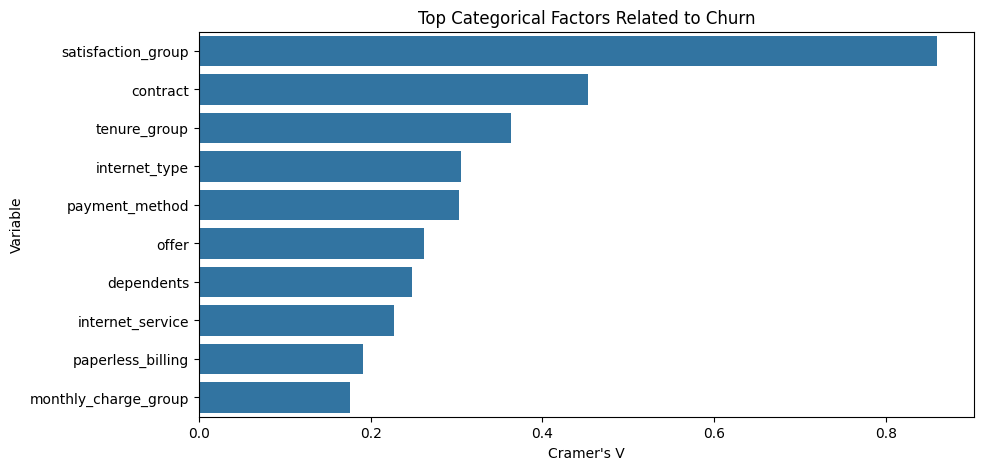

In [35]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=top_categorical_factors.head(10),
    x="cramers_v",
    y="variable"
)
plt.title("Top Categorical Factors Related to Churn")
plt.xlabel("Cramer's V")
plt.ylabel("Variable")
plt.show()

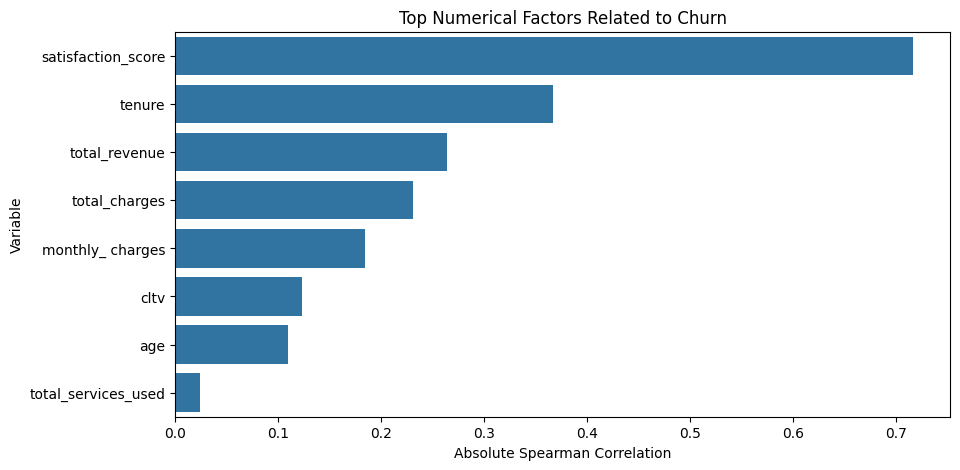

In [36]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=top_numerical_factors.head(10),
    x="abs_spearman_corr",
    y="variable"
)
plt.title("Top Numerical Factors Related to Churn")
plt.xlabel("Absolute Spearman Correlation")
plt.ylabel("Variable")
plt.show()

In [37]:
# FUNCTION: GET HIGHEST CHURN CATEGORY


def get_highest_churn_category(data, category_col):
    summary = churn_summary_by_category(data, category_col)
    highest = summary.iloc[0]

    return {
        "variable": category_col,
        "highest_category": highest[category_col],
        "total_customers": highest["total_customers"],
        "churned_customers": highest["churned_customers"],
        "churn_rate": highest["churn_rate"]
    }

In [38]:
# MAIN EDA INSIGHT SUMMARY


eda_focus_cols = [
    "satisfaction_group",
    "contract",
    "payment_method",
    "monthly_charge_group",
    "tenure_group",
    "internet_type",
    "online_security",
    "premium_tech_support",
    "cltv_segment"
]

eda_focus_cols = [col for col in eda_focus_cols if col in df_analysis.columns]

eda_insight_summary = []

for col in eda_focus_cols:
    eda_insight_summary.append(get_highest_churn_category(df_analysis, col))

eda_insight_summary_df = pd.DataFrame(eda_insight_summary)

eda_insight_summary_df

,variable,highest_category,total_customers,churned_customers,churn_rate
0,satisfaction_group,Low Satisfaction,1440,1440,100.000000
1,contract,Month-to-Month,3610,1655,45.844875
2,payment_method,Electronic check,2365,1071,45.285412
3,monthly_charge_group,High Charge,2347,800,34.086067
4,tenure_group,New Customer,1481,784,52.937205
5,internet_type,Fiber Optic,3035,1236,40.724876
6,online_security,No,5024,1574,31.329618
7,premium_tech_support,No,4999,1559,31.186237
8,cltv_segment,Low Value,2348,807,34.369676


## Churn Risk Segmentation

In [39]:
# CHURN RISK SEGMENTATION BASED ON CHURN SCORE

df_analysis["churn_risk_segment"] = pd.cut(
    df_analysis["churn_score"],
    bins=[-1, 39, 69, 100],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

df_analysis[[
    "customer_id",
    "churn_value",
    "churn_label",
    "churn_score",
    "churn_risk_segment",
    "satisfaction_score",
    "cltv"
]].head()

,customer_id,churn_value,churn_label,churn_score,churn_risk_segment,satisfaction_score,cltv
0,0002-ORFBO,0,No,65,Medium Risk,3,2205
1,0003-MKNFE,0,No,66,Medium Risk,5,5414
2,0004-TLHLJ,1,Yes,71,High Risk,1,4479
3,0011-IGKFF,1,Yes,91,High Risk,1,3714
4,0013-EXCHZ,1,Yes,68,Medium Risk,1,3464


In [40]:
# Risk Segment Summary
risk_segment_summary = df_analysis.groupby("churn_risk_segment").agg(
    total_customers=("customer_id", "nunique"),
    churned_customers=("churn_value", "sum"),
    churn_rate=("churn_value", "mean"),
    avg_churn_score=("churn_score", "mean"),
    avg_satisfaction=("satisfaction_score", "mean"),
    avg_monthly_charges=("monthly_ charges", "mean"),
    avg_tenure=("tenure", "mean"),
    avg_cltv=("cltv", "mean")
).reset_index()

risk_segment_summary["churn_rate"] = risk_segment_summary["churn_rate"] * 100
risk_segment_summary = risk_segment_summary.sort_values("churn_rate", ascending=False)

risk_segment_summary

,churn_risk_segment,total_customers,churned_customers,churn_rate,avg_churn_score,avg_satisfaction,avg_monthly_charges,avg_tenure,avg_cltv
2,High Risk,2565,1615,62.962963,80.720858,2.489669,69.453236,25.320468,4274.462378
1,Medium Risk,2799,254,9.074670,55.645230,3.618078,62.782672,35.806717,4463.759914
0,Low Risk,1679,0,0.000000,29.333532,3.776653,60.893597,37.415128,4486.731983


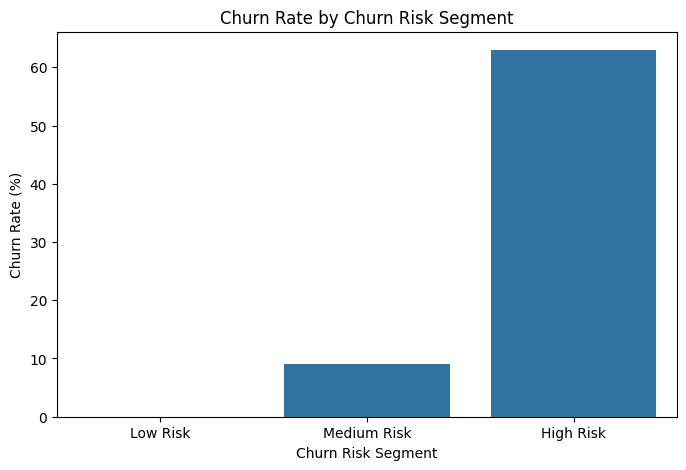

In [41]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=risk_segment_summary,
    x="churn_risk_segment",
    y="churn_rate"
)

plt.title("Churn Rate by Churn Risk Segment")
plt.xlabel("Churn Risk Segment")
plt.ylabel("Churn Rate (%)")
plt.show()

## Retention Priority based on Churn Score and CLTV

In [42]:
# RETENTION PRIORITY BASED ON CHURN SCORE AND CLTV

df_analysis["retention_priority"] = np.where(
    (df_analysis["churn_risk_segment"].astype(str) == "High Risk") &
    (df_analysis["cltv_segment"].astype(str) == "High Value"),
    "Priority Retention",
    np.where(
        df_analysis["churn_risk_segment"].astype(str) == "High Risk",
        "High Risk Monitoring",
        np.where(
            df_analysis["churn_risk_segment"].astype(str) == "Medium Risk",
            "Nurturing",
            "Regular Monitoring"
        )
    )
)

retention_priority_summary = df_analysis.groupby("retention_priority").agg(
    total_customers=("customer_id", "nunique"),
    churned_customers=("churn_value", "sum"),
    churn_rate=("churn_value", "mean"),
    avg_churn_score=("churn_score", "mean"),
    avg_satisfaction=("satisfaction_score", "mean"),
    avg_monthly_charges=("monthly_ charges", "mean"),
    avg_tenure=("tenure", "mean"),
    avg_cltv=("cltv", "mean")
).reset_index()

retention_priority_summary["churn_rate"] = retention_priority_summary["churn_rate"] * 100
retention_priority_summary = retention_priority_summary.sort_values("churn_rate", ascending=False)

retention_priority_summary

,retention_priority,total_customers,churned_customers,churn_rate,avg_churn_score,avg_satisfaction,avg_monthly_charges,avg_tenure,avg_cltv
0,High Risk Monitoring,1798,1191,66.240267,81.019466,2.422136,68.731479,21.871524,3685.962180
2,Priority Retention,767,424,55.280313,80.020860,2.647979,71.145176,33.405476,5654.023468
1,Nurturing,2799,254,9.074670,55.645230,3.618078,62.782672,35.806717,4463.759914
3,Regular Monitoring,1679,0,0.000000,29.333532,3.776653,60.893597,37.415128,4486.731983


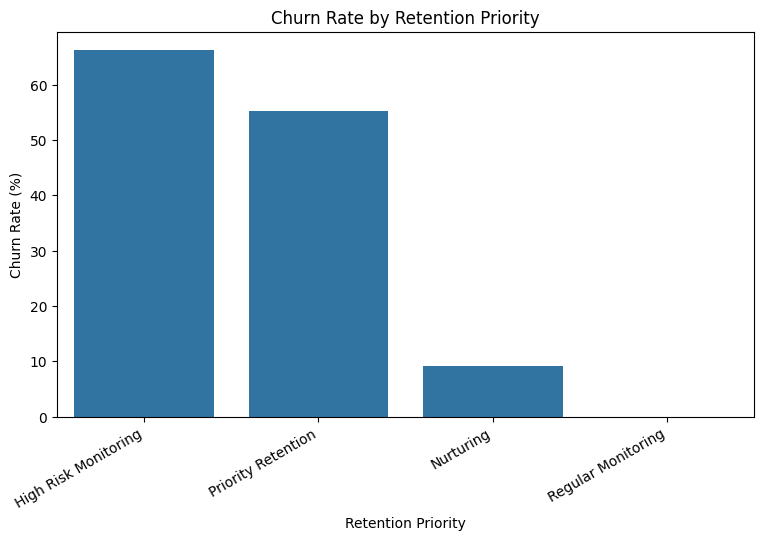

In [43]:
plt.figure(figsize=(9,5))
sns.barplot(
    data=retention_priority_summary,
    x="retention_priority",
    y="churn_rate"
)

plt.title("Churn Rate by Retention Priority")
plt.xlabel("Retention Priority")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.show()

In [44]:
# Buat folder output
output_folder = "output_powerbi"
os.makedirs(output_folder, exist_ok=True)

# Save dataset utama
df_analysis.to_csv(
    f"{output_folder}/telco_churn_final_analysis.csv",
    index=False
)

print("Dataset final berhasil disimpan:")
print(f"{output_folder}/telco_churn_final_analysis.csv")
print("Shape:", df_analysis.shape)

Dataset final berhasil disimpan:
output_powerbi/telco_churn_final_analysis.csv
Shape: (7043, 45)
